<a href="https://colab.research.google.com/github/Kash1444/Py_files/blob/main/PLACEMENT_STUDENT_DATA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Analysis of placement drive


Student ranking for placemets

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

CSV File

In [5]:
file_path = "2027 PLACEMENT DATA UPTO 5TH SEM AFTER REVAL - Sheet1.csv"

raw = pd.read_csv(file_path, header=4)

# Fix headers
raw.columns = raw.iloc[0]
df = raw.drop(0).reset_index(drop=True)

# Clean column names
df.columns = [str(col).strip().replace("\n"," ") for col in df.columns]

df.head()

,nan,S.NO,REGISTER NUMBER,STUDENTS NAME,DEPARTMENT,EMAIL ID (PERSONAL EMAIL ID),EMAIL ID (COLLEGE EMAIL ID),CONTACT NUMBER,GENDER,DATE OF BIRTH (dd/mm/yy),10TH %,12TH %,DIPLOMA %,CURRENT CGPA,No. of Current Arrears,HISTORY OF ARREARS,HIGHER STUDIES,nan
0,NaN,1,9123104002,Abhijith H,CSE,abhijithhnambiar@gmail.com,9123104002@kcgcollege.com,8778310590,MALE,6/20/2005,91.1,63.33,NaN,7.8,NIL,No,No,NaN
1,NaN,2,9123104003,ABHINAV A,COMPUTER SCIENCE AND ENGINEERING,abhinav200517@gmail.com,9123104003@kcgcollege.com,8438433772,MALE,3/17/2005,PASS (covid batch),67.50,NIL,7.5,NIL ARREAR,Yes,No,NaN
2,NaN,3,9123104004,Abinaya.M,CSE,inbamj24@gmail.com,9123104004@kcgcollege.com,9047823436,FEMALE,2/24/2006,All pass,82.00,NaN,7.6,Nill,Yes,No,NaN
3,NaN,4,9123104005,ABISHEK V,CSE,abisheikpalani@gmail.com,9123104005@kcgcollege.com,6380622694,MALE,5/13/2006,pass,78.00,NaN,8,0,No,No,NaN
4,NaN,5,9123104006,ABUBACKER SIDDHIK V A,CSE,www.abu127@gmail.com,9123104006@kcgcollege.com,9003095242,MALE,10/22/2005,72,59.20,nil,7.7,NIL ARREAR,No,No,NaN


In [6]:
df["CURRENT CGPA"] = pd.to_numeric(df["CURRENT CGPA"], errors='coerce')
df["10TH %"] = pd.to_numeric(df["10TH %"], errors='coerce')
df["12TH %"] = pd.to_numeric(df["12TH %"], errors='coerce')

In [7]:
df["Rank"] = df["CURRENT CGPA"].rank(ascending=False, method="min")

# Sort by CGPA
ranked_students = df.sort_values(by="CURRENT CGPA", ascending=False)

ranked_students[["STUDENTS NAME","REGISTER NUMBER","CURRENT CGPA","Rank"]].head(10)

,STUDENTS NAME,REGISTER NUMBER,CURRENT CGPA,Rank
91,Lalitha.B,9123104093,9.47,1.0
138,Sangamithra D,9123104141,9.46,2.0
149,Sivakumar B,9123104153,9.43,3.0
130,RITHIKA SK,9123104133,9.18,4.0
69,Jagan S,9123104071,9.10,5.0
153,Srija M,9123104159,8.96,6.0
168,Vamitha V,9123104175,8.93,7.0
19,Arun Prasanth J,9123104021,8.92,8.0
87,Keerthanaa SS,9123104089,8.90,9.0
163,Tanvi,9123104170,8.83,10.0


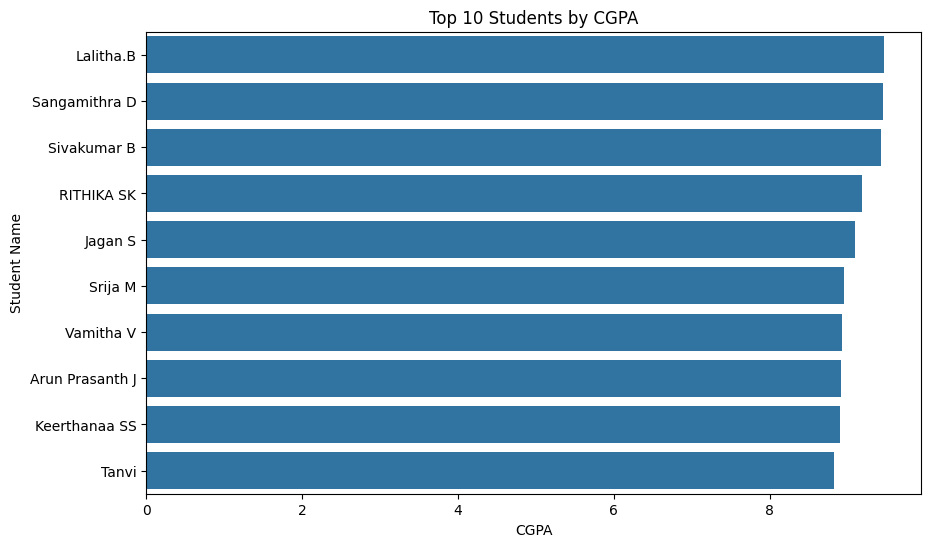

In [8]:
top10 = ranked_students.head(10)

plt.figure(figsize=(10,6))
sns.barplot(x="CURRENT CGPA", y="STUDENTS NAME", data=top10)

plt.title("Top 10 Students by CGPA")
plt.xlabel("CGPA")
plt.ylabel("Student Name")

plt.show()

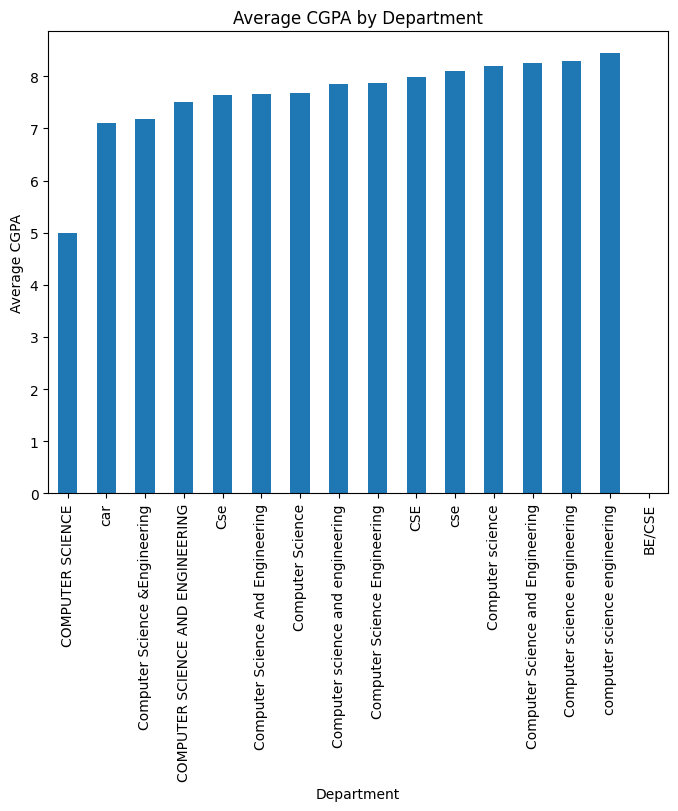

In [9]:
dept_avg = df.groupby("DEPARTMENT")["CURRENT CGPA"].mean().sort_values()

plt.figure(figsize=(8,6))

dept_avg.plot(kind='bar')

plt.title("Average CGPA by Department")
plt.xlabel("Department")
plt.ylabel("Average CGPA")

plt.show()

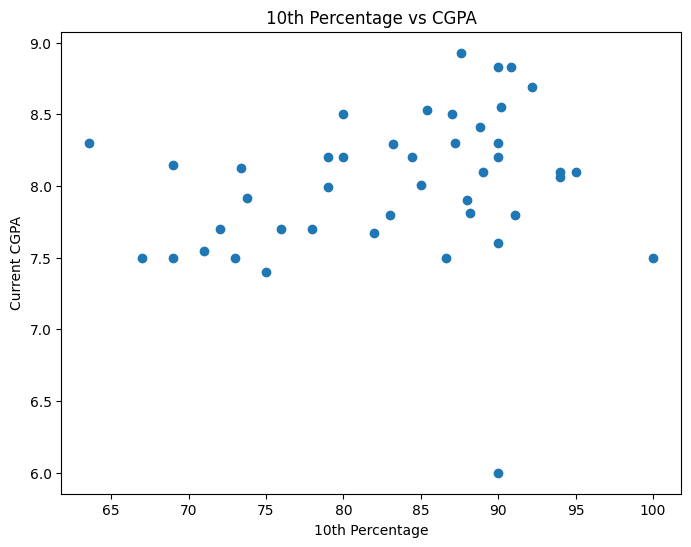

In [10]:
plt.figure(figsize=(8,6))

plt.scatter(df["10TH %"], df["CURRENT CGPA"])

plt.title("10th Percentage vs CGPA")
plt.xlabel("10th Percentage")
plt.ylabel("Current CGPA")

plt.show()

In [11]:
ranked_students.to_csv("Ranked_Students.csv", index=False)